In [61]:
import pandas as pd
import os, sys
import glob
import matplotlib.pyplot as plt
import matplotlib.lines as lns
import seaborn as sns
from tqdm import tqdm
import numpy as np
import matplotlib.ticker as mtick
from collections import defaultdict


In [62]:
folder = "results-owner-ratios"
files = [f for f in os.listdir(folder) if f.endswith(".csv") and "ZONIA_" not in f]


In [63]:
def parse_filename(filename):
    parts = filename.replace(".csv", "").split("_")

    # DIOR or CHAINLINK
    if "DIOR" in parts or "CHAINLINK" in parts or "MEDIAN" in parts:
        farmer_ratio = float(parts[3][1:])
        insurance_ratio = float(parts[4][1:])
        other_ratio = float(parts[5][1:])
        if "CHAINLINK" in parts:
            mode = "Single Device"
        elif "DIOR" in parts:
            mode = "Average"
        elif "MEDIAN":
            mode = "Median"
    # ZONIA
    else:
        farmer_ratio = float(parts[3][1:])
        insurance_ratio = float(parts[4][1:])
        other_ratio = float(parts[5][1:])
        if other_ratio == 0.0:
            mode = "ZONIA 0% others"
        elif other_ratio == 0.05:
            mode = "ZONIA 5% others"
        elif other_ratio == 0.1:
            mode = "ZONIA 10% others"
        elif other_ratio == 0.2:
            mode = "ZONIA 20% others"
        elif other_ratio == 0.3:
            mode = "ZONIA 30% others"
        else:
           return None

    return filename, round(farmer_ratio, 2), round(other_ratio, 2), mode


In [64]:
# Dictionary: {(farmer_ratio, mode): count_of_successes}
attack_success_counts = defaultdict(int)
total_counts = defaultdict(int)

for fname in files:
    filepath = os.path.join(folder, fname)
    df = pd.read_csv(filepath)

    # Skip files that don't contain the expected column
    if "consolidated_result" not in df.columns:
        continue
    
    parsed_file = parse_filename(fname)
    if parsed_file is None:
        continue
    _, farmer_ratio, _, mode = parsed_file

    total_counts[(farmer_ratio, mode)] += 1

    if True in df["consolidated_result"].values:
        attack_success_counts[(farmer_ratio, mode)] += 1


In [65]:
data = []

for (farmer_ratio, mode), total in total_counts.items():
    successes = attack_success_counts.get((farmer_ratio, mode), 0)
    data.append(
        {
            "farmer_ratio": round(farmer_ratio, 2),
            "mode": mode,
            "success_rate": successes / total,
        }
    )

plot_df = pd.DataFrame(data)


In [56]:
plot_df = plot_df[plot_df["mode"] != "ZONIA 300% others"]


In [66]:

palette = {
    "Single Device": "#C71585",
    "Average": "#FFC107",
    "Median": "#FF7F50",
    "ZONIA 0% others": "#1B2D41",
    "ZONIA 10% others": "#466C82",
    "ZONIA 20% others": "#87A0B3",
    "ZONIA 30% others": "#D1E1F2",
}

ordered_modes = [
    "Single Device",
    "Average",
    "Median",
    "ZONIA 0% others",
    "ZONIA 10% others",
    "ZONIA 20% others",
    "ZONIA 30% others",
]
style_config = {
    "Single Device": {"marker": "o", "linestyle": "-"},
    "Average": {"marker": "s", "linestyle": "--"},
    "Median": {"marker": "^", "linestyle": "-."},
    "ZONIA 0% others": {"marker": "D", "linestyle": ":"},
    "ZONIA 10% others": {"marker": "v", "linestyle": "-"},
    "ZONIA 20% others": {"marker": "P", "linestyle": "--"},
    "ZONIA 30% others": {"marker": "X", "linestyle": "-."},
}

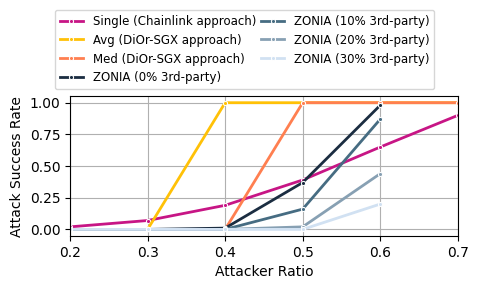

In [59]:
plot_df = plot_df[plot_df["mode"].isin(ordered_modes)].copy()
plot_df["mode"] = pd.Categorical(plot_df["mode"], categories=ordered_modes, ordered=True)

# Plot
plt.figure(figsize=(4.8, 3))
sns.lineplot(
    data=plot_df,
    x="farmer_ratio",
    y="success_rate",
    hue="mode",
    palette=palette,
    marker="o",
    markersize=3,
    linewidth=2,
    estimator=None,

)

plt.ylabel("Attack Success Rate")
plt.grid()
plt.xlabel("Attacker Ratio")
plt.xlim(0.2, 0.7)

handles, labels = plt.gca().get_legend_handles_labels()

new_labels = [
    "Single (Chainlink approach)", "Avg (DiOr-SGX approach)", "Med (DiOr-SGX approach)", "ZONIA (0% 3rd-party)", "ZONIA (10% 3rd-party)", "ZONIA (20% 3rd-party)", "ZONIA (30% 3rd-party)"
]
plt.legend(handles=handles, labels=new_labels,
           bbox_to_anchor=(0.45, 1.01), loc="lower center", ncol=2, columnspacing=0.4, fontsize=8.5)
plt.tight_layout()
plt.savefig("use_case.pdf", format="pdf", bbox_inches="tight")


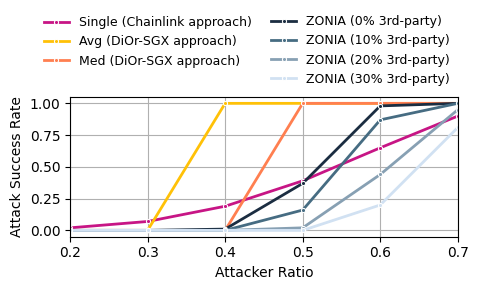

In [67]:
plot_df = plot_df[plot_df["mode"].isin(ordered_modes)].copy()
plot_df["mode"] = pd.Categorical(plot_df["mode"], categories=ordered_modes, ordered=True)

# Plot
plt.figure(figsize=(4.8, 3))
plt.grid()

sns.lineplot(
    data=plot_df,
    x="farmer_ratio",
    y="success_rate",
    hue="mode",
    palette=palette,
    marker="o",
    markersize=3,
    linewidth=2,
    estimator=None,
)

plt.ylabel("Attack Success Rate")
plt.xlabel("Attacker Ratio")
plt.xlim(0.2, 0.7)

handles, labels = plt.gca().get_legend_handles_labels()

# Split the legend items into two groups
group1_handles = handles[:3]
group1_labels = ["Single (Chainlink approach)", "Avg (DiOr-SGX approach)", "Med (DiOr-SGX approach)"]

group2_handles = handles[3:]
group2_labels = ["ZONIA (0% 3rd-party)", "ZONIA (10% 3rd-party)", "ZONIA (20% 3rd-party)", "ZONIA (30% 3rd-party)"]

# Create two separate legend objects
first_legend = plt.legend(group1_handles, group1_labels, 
                          loc='lower center', bbox_to_anchor=(0.20, 1.13),
                         ncol=1, fontsize=9, frameon=False)
plt.gca().add_artist(first_legend)

plt.legend(group2_handles, group2_labels, 
          loc='lower center', bbox_to_anchor=(0.75, 1),
          ncol=1, fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig("use_case.pdf", format="pdf", bbox_inches="tight")